## Setup:
Setting up our mutual funds. Note that we have 4 mutual funds [A,B,C,D] with the following distributions/returns:

- A: $Unif[-40\%, 60\%]$
- B: $Unif[-10\%, 24\%]$
- C: $Normal(7\%, (2\%)^2)$
- D: $Unif[5\%, 7\%]$

We will also start with `$1,000,000`. Our goal will be to determine the best investment strategy.

The code below contains several functions about portfolios, which are an array of 4 numbers indicating the amount invested in each stock respectively.

In [301]:
# %pip install numpy matplotlib
# uncomment during first run to install dependencies

import numpy as np
import matplotlib.pyplot as plt

NUM_SIMS = 100000
SEED = 0
SHORT_TERM_YEARS = 3
LONG_TERM_YEARS = 10

SHORT_TERM_SCORES = []
LONG_TERM_SCORES = []

np.random.seed(SEED)

def setup_portfolios(starting_portfolio: list[float], num_portfolios: int) -> list[list[float]]:
        return [starting_portfolio.copy() for _ in range(num_portfolios)]

# Returns a portfolio containing the mean value of each stock across all portfolios
def get_mean_portfolio(portfolios: list[list[float]]) -> np.ndarray:
        return np.mean(portfolios, axis=0)

# Returns an array of the values of a specific stock type across all portfolios
def filter_portfolios(portfolios: list[list[float]], stock_type: str) -> np.ndarray:
        
        np_arr = np.array(portfolios)

        match stock_type:
                case 'A':
                        return np_arr[:, 0]
                case 'B':
                        return np_arr[:, 1]
                case 'C':
                        return np_arr[:, 2]
                case 'D':
                        return np_arr[:, 3]
                case _:
                        raise ValueError(f"Invalid stock type: {stock_type}")

# Returns an array containing the total value of each portfolio
def get_portfolio_totals(portfolios: list[list[float]]) -> np.ndarray:
        return np.sum(portfolios, axis=1)

# Returns the number of values that have a total value greater than the threshold
def percent_of_values_above(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values > threshold) / len(values) * 100

# Returns the number of values that have a total value less than or equal to the threshold
def percent_of_values_below(values: np.ndarray, threshold: float) -> float:
        return np.count_nonzero(values <= threshold) / len(values) * 100

def percent_of_return(end, start) -> float:
        return (end - start) / start * 100

def percent_of_outliers(values: np.ndarray) -> float:
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr = q75 - q25
        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr
        outliers = np.sum((values < lower_bound) | (values > upper_bound))
        return outliers / len(values) * 100

def get_scores(values: np.ndarray) -> list[int]:
        q25 = np.percentile(values, 25)
        median = np.median(values)
        q75 = np.percentile(values, 75)

        risk_averse_score = int((0.5 * q25 + 0.4 * median + 0.1 * q75) // 1000)
        risk_neutral_score = int((0.1 * q25 + 0.8 * median + 0.1 * q75) // 1000)
        risk_seeking_score = int((0.1 * q25 + 0.6 * median + 0.3 * q75) // 1000)

        return [risk_averse_score, risk_neutral_score, risk_seeking_score]

def print_stats(values: np.ndarray, header: str = "Stats:", footer: str = ""):
        mean = np.mean(values)
        median = np.median(values)
        q25 = np.percentile(values, 25)
        q75 = np.percentile(values, 75)
        iqr_value = q75 - q25
        outlier_percentage = percent_of_outliers(values)
        std = np.std(values)
        scores = get_scores(values)

        print(
                f"{header}\n"
                f"Mean: ${mean:,.2f}\n"
                f"Mean return: {percent_of_return(mean, 1000000):.2f}%\n"
                f"Standard Deviation: ${std:,.2f}\n\n"
                
                f"Median: ${median:,.2f}\n"
                f"Median return: {percent_of_return(median, 1000000):.2f}%\n"
                f"Min: ${np.min(values):,.2f}\n"
                f"Max: ${np.max(values):,.2f}\n"
                f"Q1 (25th percentile): ${q25:,.2f}\n"
                f"Q3 (75th percentile): ${q75:,.2f}\n"
                f"IQR: ${iqr_value:,.2f}\n\n"

                f"Percentage of failed portfolios: {percent_of_values_below(values, 1000000):.2f}%\n"
                f"Percentage of outliers: {outlier_percentage:.2f}%\n\n"

                f"Risk-averse score: {scores[0]}\n"
                f"Risk-neutral score: {scores[1]}\n"
                f"Risk-seeking score: {scores[2]}\n"
                f"{footer}"
        )

# Simulates one year of returns for a single portfolio
def simulate_once(portfolio: list[float]):
        change_a = np.random.uniform(-0.4, 0.6)
        change_b = np.random.uniform(-0.1, 0.24)
        change_c = np.random.normal(0.07, 0.02)
        change_d = np.random.uniform(0.05, 0.07)

        portfolio[0] *= (1 + change_a)
        portfolio[1] *= (1 + change_b)
        portfolio[2] *= (1 + change_c)
        portfolio[3] *= (1 + change_d)

# Simulates multiple years of returns for a list of portfolios
def simulate_multiple(portfolios: list[list[float]], num_years: int):
        for _ in range(num_years):
                for portfolio in portfolios:
                        simulate_once(portfolio)

### Question 1:

##### What is the expected return if you invest option A for 3 years? 

In [302]:
starting_portfolio = [1000000.0, 1000000.0, 1000000.0, 1000000.0]  # do all 4 stock simulations at once
portfolios = setup_portfolios(starting_portfolio, NUM_SIMS)

simulate_multiple(portfolios, SHORT_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
SHORT_TERM_SCORES.append(get_scores(fund_A_values))
print_stats(fund_A_values, header="+ Fund A stats after 3 years:")

+ Fund A stats after 3 years:
Mean: $1,332,978.55
Mean return: 33.30%
Standard Deviation: $628,224.01

Median: $1,215,037.73
Median return: 21.50%
Min: $232,680.14
Max: $4,032,441.91
Q1 (25th percentile): $858,540.94
Q3 (75th percentile): $1,689,778.17
IQR: $831,237.23

Percentage of failed portfolios: 35.17%
Percentage of outliers: 1.99%

Risk-averse score: 1084
Risk-neutral score: 1226
Risk-seeking score: 1321



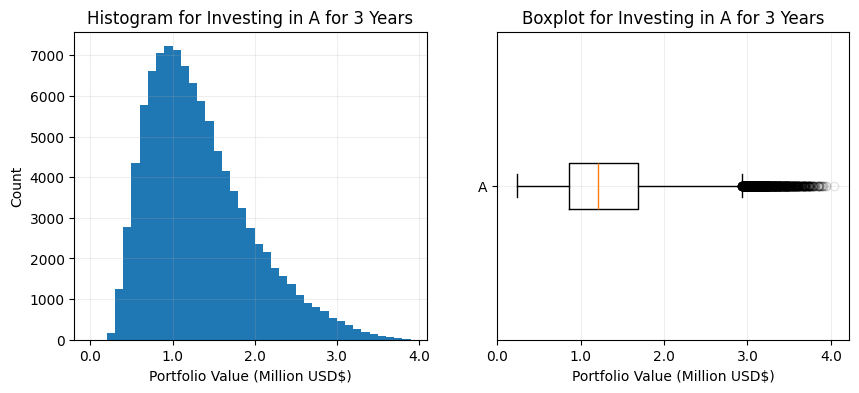

In [303]:
# plots for fund A

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_A_values, bins=range(0, 4000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in A for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 4.01, 1)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in A for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 4.01, 1)))
ax2.set_yticklabels(["A"])

plt.show()

##### What is the probability that your profit is more than 25%? 

$ P(T > 1,250,000) =  ? $

In [304]:
print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_A_values, 1250000):.2f}%")

Percentage of portfolios with over $1,250,000 after 3 years: 47.73%


##### What is the probability that you lose 25% of your money?

$ P(T \le 750,000) = ?$

In [305]:
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_A_values, 750000):.2f}%")

Percentage of portfolios with $750,000 or less after 3 years: 17.59%


### Question 2:
##### What are your answers if you invest in fund B or C? And what is your recommendation for the best option?

In [306]:
# calculations for fund B
fund_B_values = filter_portfolios(portfolios, "B")
SHORT_TERM_SCORES.append(get_scores(fund_B_values))
print_stats(fund_B_values, header="+ Fund B stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_B_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_B_values, 750000):.2f}%")

+ Fund B stats after 3 years:
Mean: $1,225,102.33
Mean return: 22.51%
Standard Deviation: $195,195.23

Median: $1,211,819.07
Median return: 21.18%
Min: $741,571.19
Max: $1,886,874.72
Q1 (25th percentile): $1,081,580.09
Q3 (75th percentile): $1,355,228.16
IQR: $273,648.07

Percentage of failed portfolios: 12.16%
Percentage of outliers: 0.32%

Risk-averse score: 1161
Risk-neutral score: 1213
Risk-seeking score: 1241

Percentage of portfolios with over $1,250,000 after 3 years: 42.71%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


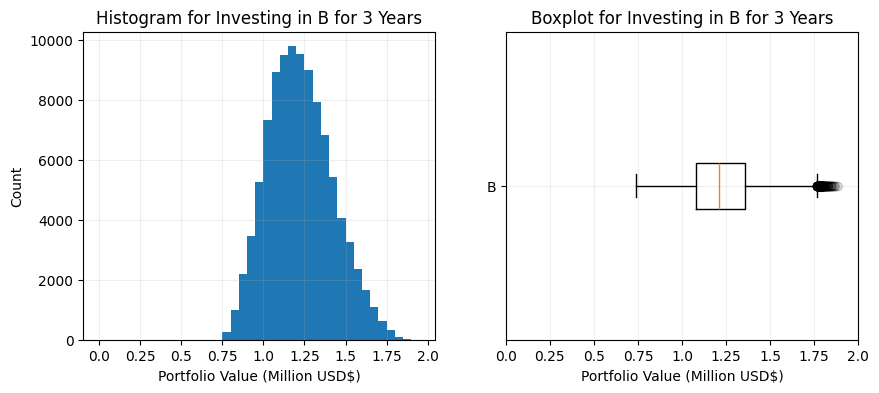

In [307]:
# plots for fund B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_B_values, bins=range(0, 2000000, 50000)) # each bin will be 50k
ax1.set_xticks(ticks=range(0,2000000,200000))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in B for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 2000001, 250000), labels=list(np.arange(0, 2.01, 0.25)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in B for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 2000001, 250000), labels=list(np.arange(0, 2.01, 0.25)))
ax2.set_yticklabels(["B"])

plt.show()


In [308]:
# calculations for fund C
fund_C_values = filter_portfolios(portfolios, "C")
SHORT_TERM_SCORES.append(get_scores(fund_C_values))
print_stats(fund_C_values, header="+ Fund C stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_C_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_C_values, 750000):.2f}%")


+ Fund C stats after 3 years:
Mean: $1,225,044.17
Mean return: 22.50%
Standard Deviation: $39,682.91

Median: $1,224,593.25
Median return: 22.46%
Min: $1,052,171.33
Max: $1,402,065.01
Q1 (25th percentile): $1,197,999.20
Q3 (75th percentile): $1,251,745.71
IQR: $53,746.51

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.63%

Risk-averse score: 1214
Risk-neutral score: 1224
Risk-seeking score: 1230

Percentage of portfolios with over $1,250,000 after 3 years: 26.40%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


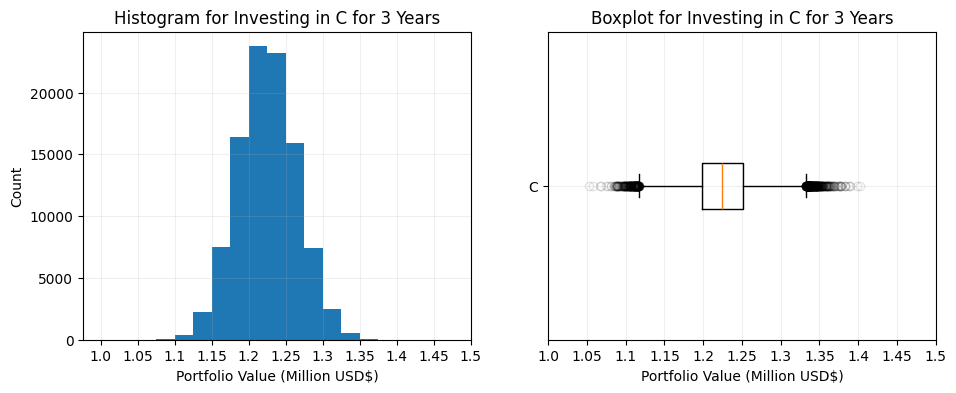

In [309]:
# plots for fund C

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

histogram = ax1.hist(fund_C_values, bins=range(1000000, 1500000, 25000)) # each bin will be 25k
ax1.set_xticks(ticks=range(1000000,1500000,50000))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 1500001, 50000), labels=list(np.round(np.arange(1, 1.51, 0.05), 3)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 1500001, 50000), labels=list(np.round(np.arange(1, 1.51, 0.05), 3)))
ax2.set_yticklabels(["C"])

plt.show()


##### What about investing everything in fund D for 3 years?

In [310]:
# calculations for fund D
fund_D_values = filter_portfolios(portfolios, "D")
SHORT_TERM_SCORES.append(get_scores(fund_D_values))
print_stats(fund_D_values, header="+ Fund D stats after 3 years:")

print(f"Percentage of portfolios with over $1,250,000 after {SHORT_TERM_YEARS} years: {percent_of_values_above(fund_D_values, 1250000):.2f}%")
print(f"Percentage of portfolios with $750,000 or less after {SHORT_TERM_YEARS} years: {percent_of_values_below(fund_D_values, 750000):.2f}%")

+ Fund D stats after 3 years:
Mean: $1,191,083.07
Mean return: 19.11%
Standard Deviation: $11,251.28

Median: $1,191,020.76
Median return: 19.10%
Min: $1,158,370.78
Max: $1,224,486.87
Q1 (25th percentile): $1,183,089.18
Q3 (75th percentile): $1,199,041.38
IQR: $15,952.20

Percentage of failed portfolios: 0.00%
Percentage of outliers: 0.02%

Risk-averse score: 1187
Risk-neutral score: 1191
Risk-seeking score: 1192

Percentage of portfolios with over $1,250,000 after 3 years: 0.00%
Percentage of portfolios with $750,000 or less after 3 years: 0.00%


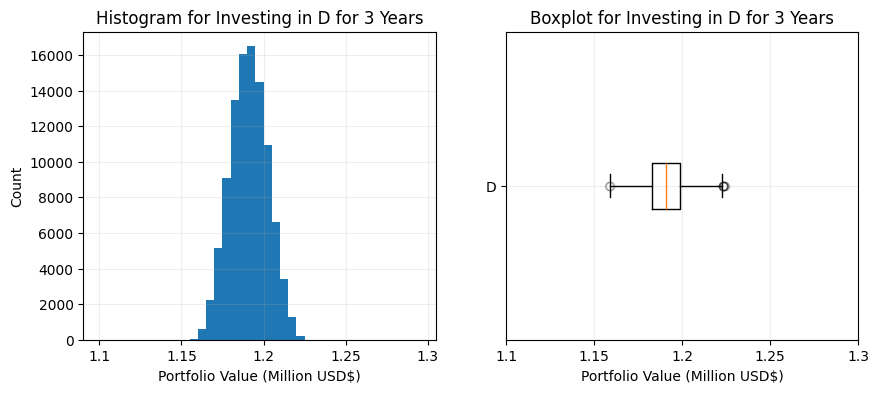

In [311]:
# plots for fund D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_D_values, bins=range(1100000, 1300000, 5000)) # each bin will be 5k
ax1.set_xticks(ticks=range(1100000,1300001,50000), labels=list(np.round((np.arange(1.1, 1.31, 0.05)), decimals=2)))
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(ticks=range(1100000,1300001,50000), labels=list(np.round((np.arange(1.1, 1.31, 0.05)), decimals=2)))
ax2.set_yticklabels(["D"])

plt.show()


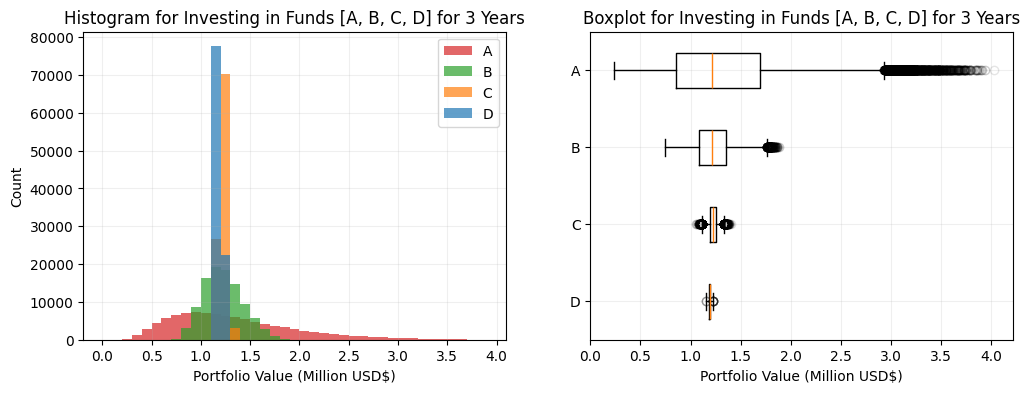

In [312]:
# combining outcomes for funds A, B, C, D into into a single plot for simplicity

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

stacked_hist = ax1.hist([fund_D_values, fund_C_values, fund_B_values, fund_A_values], histtype="stepfilled", bins=range(0, 4000000, 100000), label=["D", "C", "B", "A"], alpha=0.7)
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in Funds [A, B, C, D] for 3 Years")
ax1.legend()
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 500000), labels=list(np.arange(0, 4.01, 0.5)))
ax1.set_ylabel("Count")

multi_boxplot = ax2.boxplot([fund_D_values, fund_C_values, fund_B_values, fund_A_values], label=["D", "C", "B", "A"], vert=False, flierprops={"alpha": 0.1})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in Funds [A, B, C, D] for 3 Years")
ax2.set_xticks(range(0, 4000001, 500000), labels=list(np.arange(0, 4.01, 0.5)))
ax2.set_yticks(ticks=[1,2,3,4], labels=["D", "C", "B", "A"])
ax2.set_xlabel("Portfolio Value (Million USD$)")
plt.show()

### Question 3:
##### How will your answer/recommendation change if you are planning for 10 years, instead of 3 years?

In [313]:
portfolios = setup_portfolios([1000000.0, 1000000.0, 1000000.0, 1000000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

fund_A_values = filter_portfolios(portfolios, "A")
fund_B_values = filter_portfolios(portfolios, "B")
fund_C_values = filter_portfolios(portfolios, "C")
fund_D_values = filter_portfolios(portfolios, "D")

LONG_TERM_SCORES.append(get_scores(fund_A_values))
LONG_TERM_SCORES.append(get_scores(fund_B_values))
LONG_TERM_SCORES.append(get_scores(fund_C_values))
LONG_TERM_SCORES.append(get_scores(fund_D_values))

Here are some statistics about the funds:

In [314]:
print_stats(fund_A_values, "+ Fund A stats after 10 years:")
print_stats(fund_B_values, "+ Fund B stats after 10 years:")
print_stats(fund_C_values, "+ Fund C stats after 10 years:")
print_stats(fund_D_values, "+ Fund D stats after 10 years:")

+ Fund A stats after 10 years:
Mean: $2,588,001.37
Mean return: 158.80%
Standard Deviation: $2,491,665.52

Median: $1,823,984.31
Median return: 82.40%
Min: $48,099.65
Max: $36,668,648.54
Q1 (25th percentile): $1,001,964.89
Q3 (75th percentile): $3,284,835.49
IQR: $2,282,870.61

Percentage of failed portfolios: 24.92%
Percentage of outliers: 6.28%

Risk-averse score: 1559
Risk-neutral score: 1887
Risk-seeking score: 2180

+ Fund B stats after 10 years:
Mean: $1,964,207.71
Mean return: 96.42%
Standard Deviation: $577,245.60

Median: $1,888,561.51
Median return: 88.86%
Min: $486,470.36
Max: $5,609,621.65
Q1 (25th percentile): $1,546,283.13
Q3 (75th percentile): $2,300,943.13
IQR: $754,660.00

Percentage of failed portfolios: 1.59%
Percentage of outliers: 1.71%

Risk-averse score: 1758
Risk-neutral score: 1895
Risk-seeking score: 1978

+ Fund C stats after 10 years:
Mean: $1,966,873.81
Mean return: 96.69%
Standard Deviation: $116,125.12

Median: $1,963,680.60
Median return: 96.37%
Min: $1,

Here are the plots:

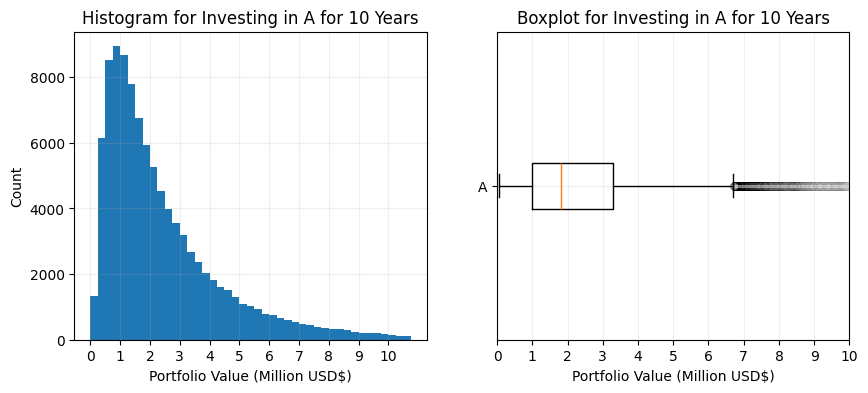

In [315]:
# fund A

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_A_values, bins=range(0, 11000000, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in A for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0,11000000, 1000000), list(range(0,11))) # type: ignore
ax1.set_ylabel("Count")


box_plot = ax2.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.005})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in A for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 11000000, 1000000), list(range(0,11))) # type: ignore
ax2.set_yticks([1], ["A"])
ax2.set_xlim(0,10000000)

plt.show()

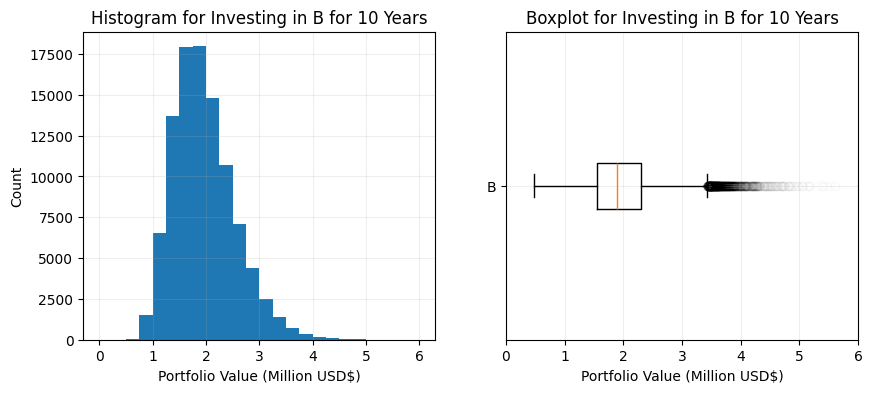

In [316]:
# fund B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_B_values, bins=range(0, 6000001, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in B for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0,6000001, 1000000), list(range(0,7))) # type: ignore
ax1.set_ylabel("Count")


box_plot = ax2.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in B for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 6000001, 1000000), list(range(0,7))) # type: ignore
ax2.set_yticks([1], ["B"])
ax2.set_xlim(0,6000001) 

plt.show()

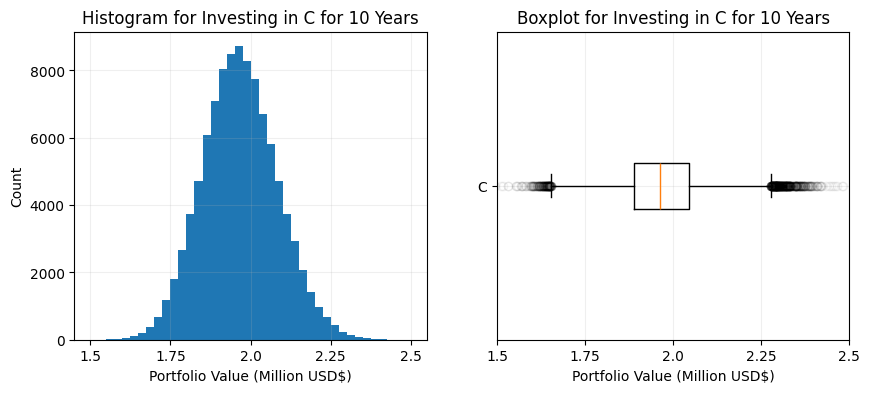

In [317]:
# fund C

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_C_values, bins=range(1500000, 2500001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1500000,2500001, 250000), list(np.arange(1.5, 2.6, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1500000, 2500001, 250000), list(np.arange(1.5, 2.6, 0.25))) # type: ignore
ax2.set_yticks([1], ["C"])
ax2.set_xlim(1500000,2500001)

plt.show()

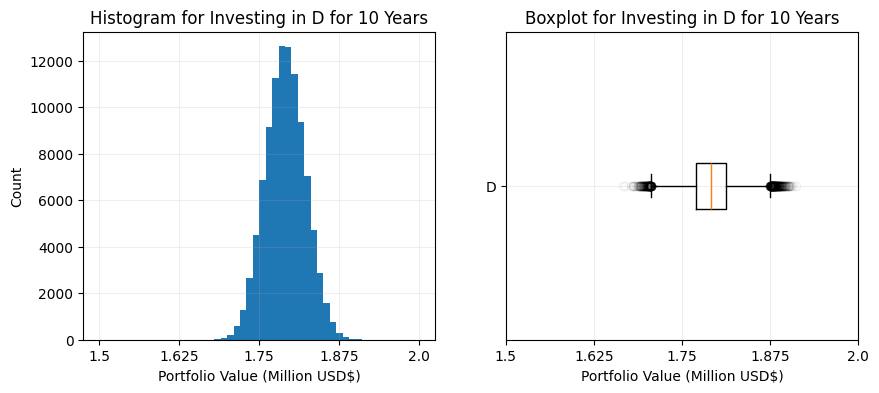

In [318]:
# fund D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

histogram = ax1.hist(fund_D_values, bins=range(1500000, 2000001, 10000)) # each bin will be 10k
ax1.grid(alpha=0.2)
ax1.set_title("Histogram for Investing in D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1500000, 2000001, 125000), list(np.arange(1.5, 2.01, 0.125))) # type: ignore
ax1.set_ylabel("Count")
	
box_plot = ax2.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title("Boxplot for Investing in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1500000, 2000001, 125000), list(np.arange(1.5, 2.01, 0.125))) # type: ignore
ax2.set_yticks([1], ["D"])
ax2.set_xlim(1500000,2000001)

plt.show()

### Question 4:

##### Will it be a better strategy if we invest `$500,000` in fund A and `$500,000` in fund D? 

First, let's start with simulating 3 years:

In [319]:
portfolios = setup_portfolios([500000.0, 0, 0, 500000.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,262,295.17
Mean return: 26.23%
Standard Deviation: $314,042.74

Median: $1,203,285.11
Median return: 20.33%
Min: $703,247.41
Max: $2,557,511.72
Q1 (25th percentile): $1,024,907.57
Q3 (75th percentile): $1,439,777.73
IQR: $414,870.16

Percentage of failed portfolios: 21.50%
Percentage of outliers: 2.00%

Risk-averse score: 1137
Risk-neutral score: 1209
Risk-seeking score: 1256



Graphs for 3 year simulation:

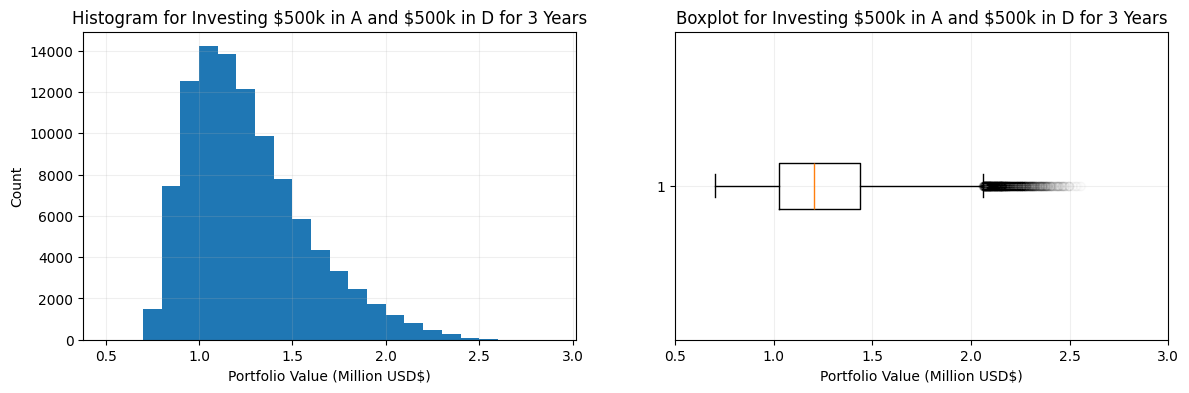

In [320]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(500000, 3000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A and \$500k in D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(500000,3000001, 500000), labels=list(np.arange(0.5, 3.01, 0.5)))
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A and \$500k in D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(500000,3000001, 500000), labels=list(np.arange(0.5, 3.01, 0.5)))

plt.show()

Now let's simulate for 10 years:

In [321]:
portfolios = setup_portfolios([500000.0, 0, 0, 500000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,190,769.19
Mean return: 119.08%
Standard Deviation: $1,266,816.34

Median: $1,810,101.95
Median return: 81.01%
Min: $898,369.77
Max: $23,458,054.43
Q1 (25th percentile): $1,393,907.35
Q3 (75th percentile): $2,535,945.78
IQR: $1,142,038.43

Percentage of failed portfolios: 0.78%
Percentage of outliers: 6.27%

Risk-averse score: 1674
Risk-neutral score: 1841
Risk-seeking score: 1986



Graphs for 10 year simulation:

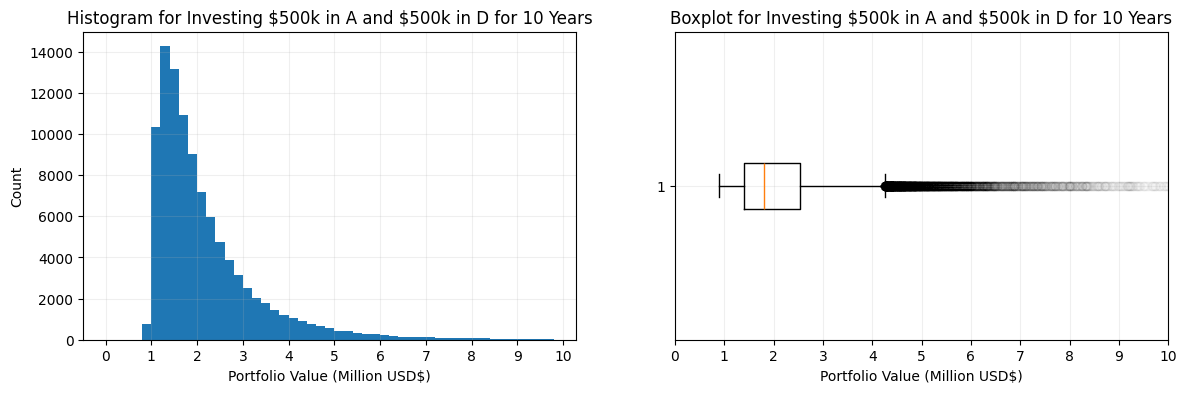

In [322]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 10000000, 200000)) # each bin will be 200k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A and \$500k in D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 10000001, 1000000), list(range(0, 11))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A and \$500k in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0,10000001, 1000000), list(range(0, 11))) # type: ignore
ax2.set_xlim(0, 10000000)

plt.show()

##### Or how about `$600,000` in fund B and `$400,000` in fund C?

We again start by simulating 3 years:

In [323]:
portfolios = setup_portfolios([0, 600000.0, 400000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,224,919.23
Mean return: 22.49%
Standard Deviation: $118,308.02

Median: $1,217,299.27
Median return: 21.73%
Min: $904,917.90
Max: $1,634,671.94
Q1 (25th percentile): $1,138,119.56
Q3 (75th percentile): $1,303,330.05
IQR: $165,210.49

Percentage of failed portfolios: 1.41%
Percentage of outliers: 0.39%

Risk-averse score: 1186
Risk-neutral score: 1217
Risk-seeking score: 1235



Graphs for 3 year simulation:

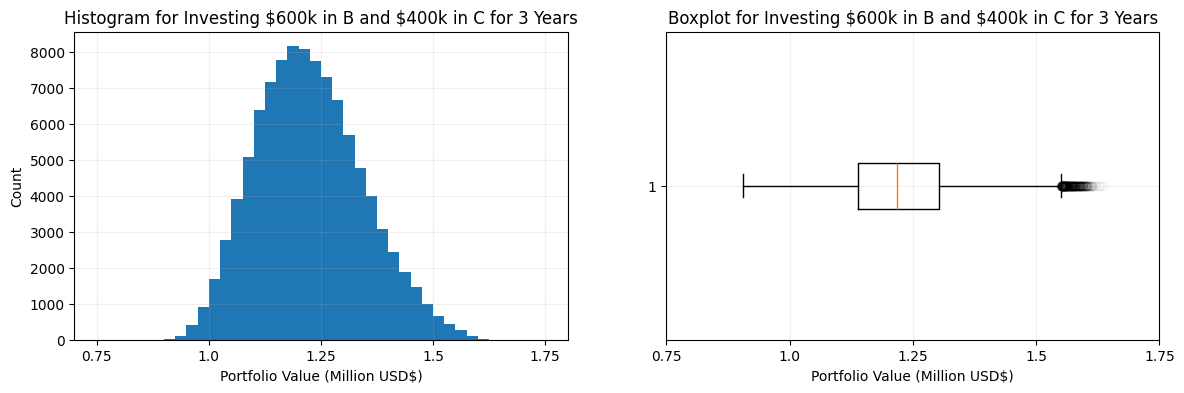

In [324]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 1750001, 25000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 1750001, 250000), labels=list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 1750001, 250000), labels=list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax2.set_xlim(750000, 1750001)

plt.show()

Now to simulate for 10 years:

In [325]:
portfolios = setup_portfolios([0, 600000.0, 400000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,964,527.61
Mean return: 96.45%
Standard Deviation: $354,702.57

Median: $1,915,954.34
Median return: 91.60%
Min: $1,078,865.52
Max: $4,386,353.37
Q1 (25th percentile): $1,708,124.66
Q3 (75th percentile): $2,170,451.61
IQR: $462,326.95

Percentage of failed portfolios: 0.00%
Percentage of outliers: 1.81%

Risk-averse score: 1837
Risk-neutral score: 1920
Risk-seeking score: 1971



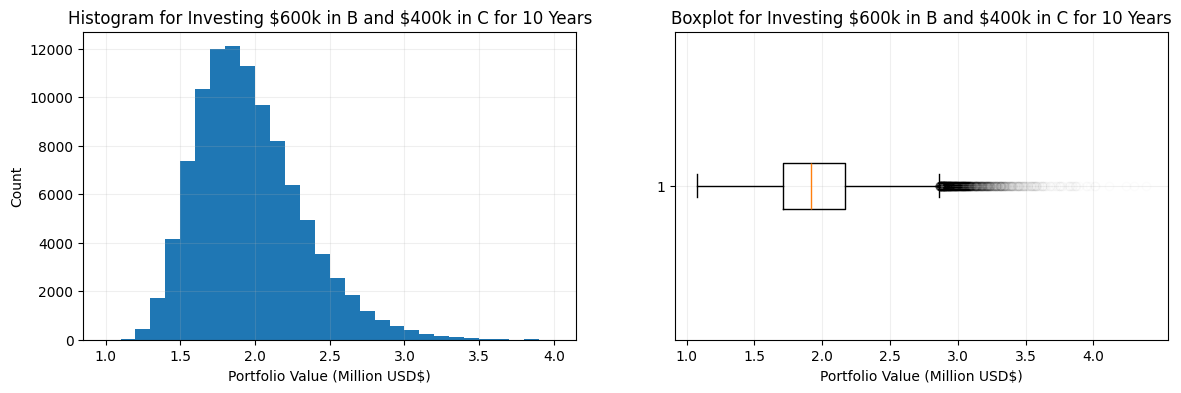

In [326]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(1000000, 4000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 4000001, 500000), list(np.arange(1, 4.1, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 4000001, 500000), list(np.arange(1, 4.1, 0.5))) # type: ignore
plt.show()

##### Or how about `$800,000` in fund A and `$200,000` in fund C?

We again start by simulating 3 years:

In [327]:
portfolios = setup_portfolios([800000.0, 0.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,311,402.81
Mean return: 31.14%
Standard Deviation: $503,740.28

Median: $1,215,863.18
Median return: 21.59%
Min: $424,511.30
Max: $3,472,868.48
Q1 (25th percentile): $931,842.78
Q3 (75th percentile): $1,595,215.24
IQR: $663,372.46

Percentage of failed portfolios: 31.12%
Percentage of outliers: 2.07%

Risk-averse score: 1111
Risk-neutral score: 1225
Risk-seeking score: 1301



Graphs for 3 year simulation:

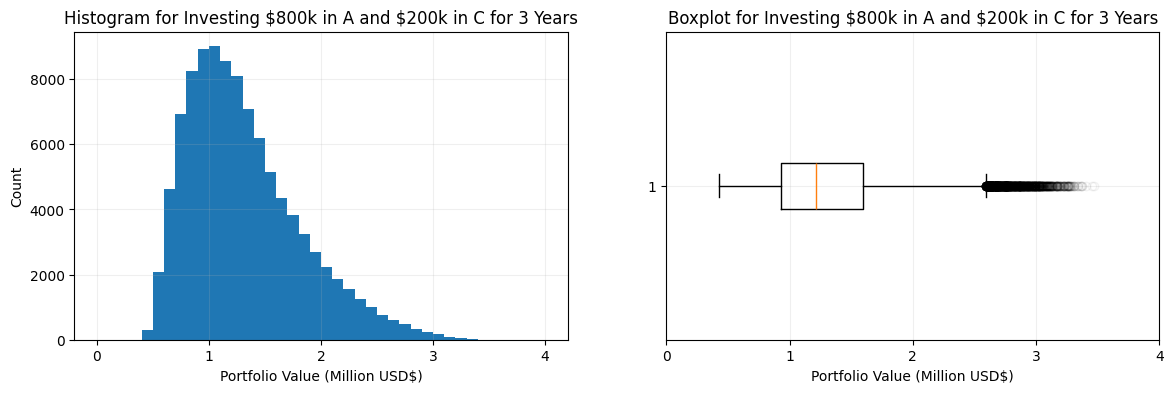

In [328]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 4000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$800k in A and \$200k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 5, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.05})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$800k in A and \$200k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 4000001, 1000000), labels=list(np.arange(0, 5, 1))) # type: ignore
ax2.set_xlim(0, 4000001)

plt.show()

Now to simulate for 10 years:

In [329]:
portfolios = setup_portfolios([800000.0, 0.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,470,605.31
Mean return: 147.06%
Standard Deviation: $2,030,618.56

Median: $1,849,556.91
Median return: 84.96%
Min: $404,334.42
Max: $43,979,281.90
Q1 (25th percentile): $1,189,482.85
Q3 (75th percentile): $3,021,543.17
IQR: $1,832,060.32

Percentage of failed portfolios: 16.48%
Percentage of outliers: 6.42%

Risk-averse score: 1636
Risk-neutral score: 1900
Risk-seeking score: 2135



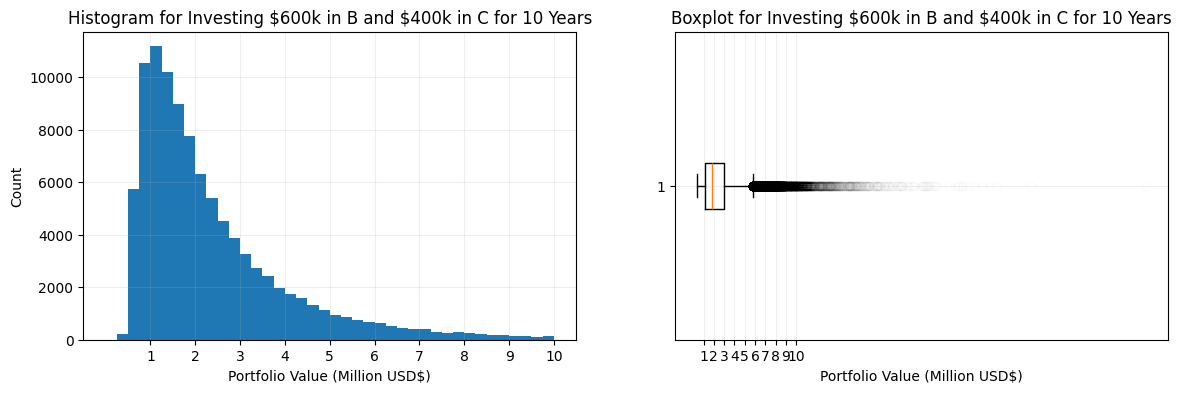

In [330]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 10000001, 250000)) # each bin will be 250k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$600k in B and \$400k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 10000001, 1000000), list(np.arange(1, 11, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$600k in B and \$400k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 10000001, 1000000), list(np.arange(1, 11, 1))) # type: ignore
plt.show()

##### Will it be a better strategy if we invest `$500,000` in fund A, `$300,000` in fund B and `$200,000` in fund C?

We start with simulating for 3 years:

In [331]:
portfolios = setup_portfolios([500000.0, 300000.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,278,216.26
Mean return: 27.82%
Standard Deviation: $319,459.36

Median: $1,221,502.73
Median return: 22.15%
Min: $634,855.18
Max: $2,670,818.76
Q1 (25th percentile): $1,039,045.31
Q3 (75th percentile): $1,460,236.85
IQR: $421,191.54

Percentage of failed portfolios: 19.72%
Percentage of outliers: 1.91%

Risk-averse score: 1154
Risk-neutral score: 1227
Risk-seeking score: 1274



Graphs for 3 years:

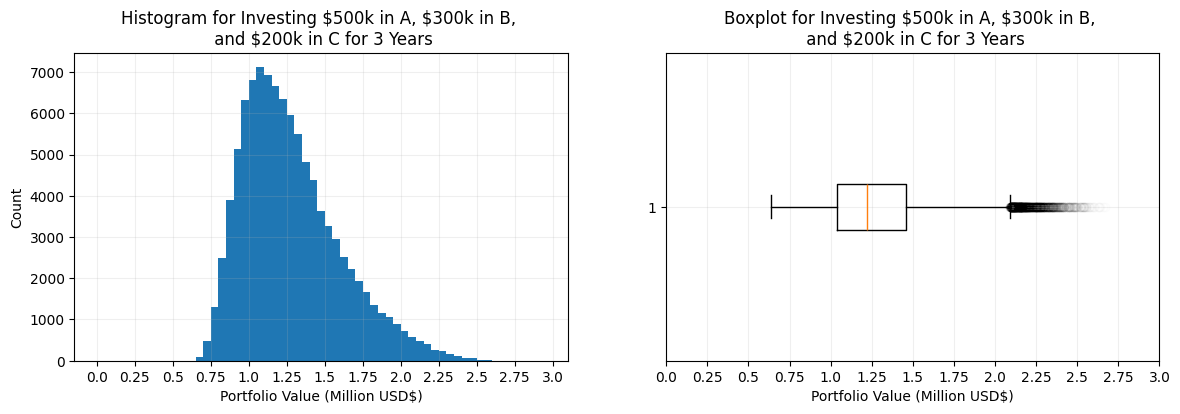

In [332]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, range(0, 3000000, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 3000001, 250000), list(np.arange(0, 3.1, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 3000001, 250000), list(np.arange(0, 3.1, 0.25))) # type: ignore

plt.show()

Now we simulate for 10 years:

In [333]:
portfolios = setup_portfolios([500000.0, 300000.0, 200000.0, 0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,273,653.00
Mean return: 127.37%
Standard Deviation: $1,268,788.28

Median: $1,908,680.00
Median return: 90.87%
Min: $680,487.43
Max: $19,892,728.30
Q1 (25th percentile): $1,477,607.35
Q3 (75th percentile): $2,637,367.10
IQR: $1,159,759.75

Percentage of failed portfolios: 1.58%
Percentage of outliers: 6.13%

Risk-averse score: 1766
Risk-neutral score: 1938
Risk-seeking score: 2084



Graphs for 10 year simulation:

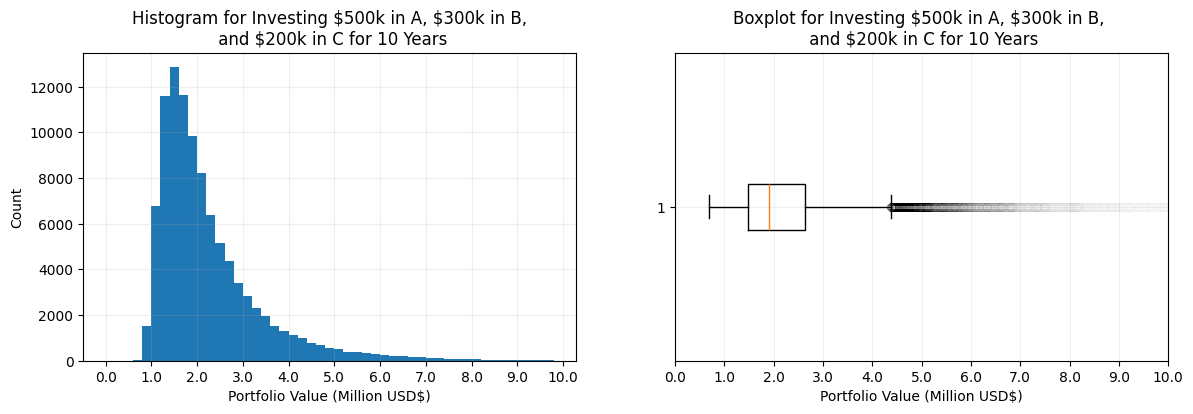

In [334]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 10000000, 200000)) # each bin will be 200k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$500k in A, \$300k in B," + "\n " \
r"and \$200k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 10000001, 1000000), list(np.arange(0, 10.1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.005})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing \$500k in A, \$300k in B, " + "\n " \
r"and \$200k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(0, 10000000)
ax2.set_xticks(range(0, 10000001, 1000000), list(np.arange(0, 10.1))) # type: ignore

plt.show()

##### How about investing `$100,000` in A, `$200,000` in B, and `$700,000` in C?

We start with simulating for 3 years:

In [335]:
portfolios = setup_portfolios([100000.0, 200000.0, 700000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,235,488.29
Mean return: 23.55%
Standard Deviation: $78,677.54

Median: $1,228,390.43
Median return: 22.84%
Min: $985,674.61
Max: $1,627,441.02
Q1 (25th percentile): $1,179,675.39
Q3 (75th percentile): $1,284,061.22
IQR: $104,385.83

Percentage of failed portfolios: 0.00%
Percentage of outliers: 1.24%

Risk-averse score: 1209
Risk-neutral score: 1229
Risk-seeking score: 1240



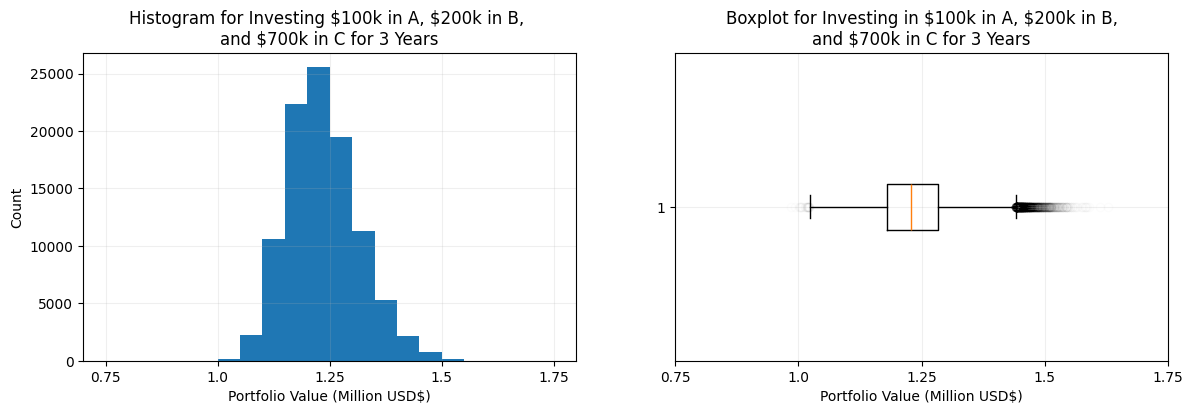

In [336]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 1750001, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$100k in A, \$200k in B, " + "\n" \
r"and \$700k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 1750001, 250000), list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$100k in A, \$200k in B," + "\n" \
r"and \$700k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 1750001, 250000), list(np.arange(0.75, 1.751, 0.25))) # type: ignore
ax2.set_xlim(750000, 1750001)

plt.show()

Now we simulate for 10 years.

In [337]:
portfolios = setup_portfolios([100000.0, 200000.0, 700000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,029,221.04
Mean return: 102.92%
Standard Deviation: $288,981.87

Median: $1,975,179.08
Median return: 97.52%
Min: $1,306,099.43
Max: $5,663,892.34
Q1 (25th percentile): $1,841,093.88
Q3 (75th percentile): $2,149,098.48
IQR: $308,004.60

Percentage of failed portfolios: 0.00%
Percentage of outliers: 4.10%

Risk-averse score: 1925
Risk-neutral score: 1979
Risk-seeking score: 2013



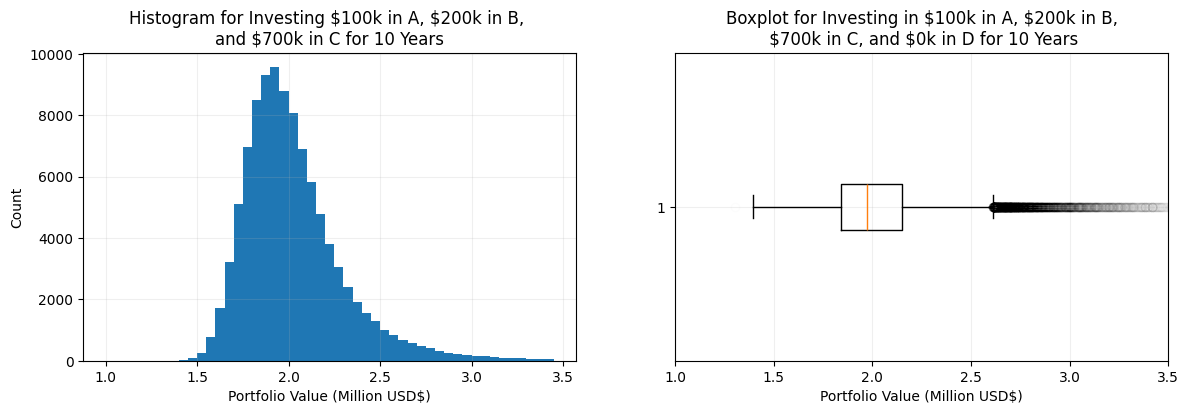

In [338]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(1000000, 3500000, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$100k in A, \$200k in B, " + "\n" \
r"and \$700k in C for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 3500001, 500000), list(np.arange(1, 3.51, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$100k in A, \$200k in B," + "\n" \
r" \$700k in C, and \$0k in D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(1000000, 3500001, 500000), list(np.arange(1, 3.51, 0.5))) # type: ignore
ax2.set_xlim(1000000, 3500001)

plt.show()

##### How about investing `$150,000` in A, `$750,000` in B, and `$100,000` in C?

We start with simulating for 3 years:

In [339]:
portfolios = setup_portfolios([150000.0, 750000.0, 100000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,240,754.22
Mean return: 24.08%
Standard Deviation: $174,017.10

Median: $1,229,658.26
Median return: 22.97%
Min: $745,419.78
Max: $2,020,942.46
Q1 (25th percentile): $1,114,919.30
Q3 (75th percentile): $1,354,782.47
IQR: $239,863.16

Percentage of failed portfolios: 7.34%
Percentage of outliers: 0.62%

Risk-averse score: 1184
Risk-neutral score: 1230
Risk-seeking score: 1255



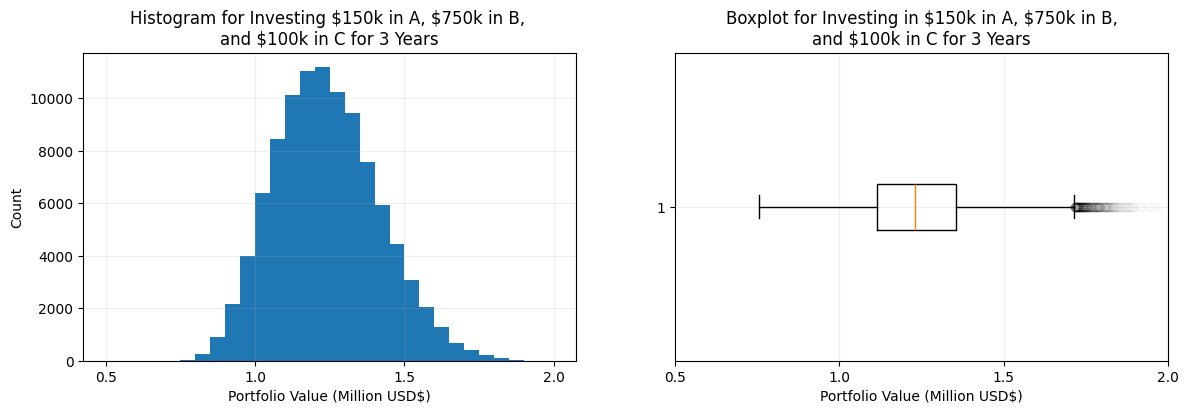

In [340]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(500000, 2000001, 50000)) # each bin will be 50k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$150k in A, \$750k in B, " + "\n" \
r"and \$100k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(500000, 2000001, 500000), list(np.arange(0.5, 2.01, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$150k in A, \$750k in B," + "\n" \
r"and \$100k in C for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(500000, 2000001, 500000), list(np.arange(0.5, 2.01, 0.5))) # type: ignore
ax2.set_xlim(500000, 2000001)

plt.show()

Now we simulate for 10 years.

In [341]:
portfolios = setup_portfolios([150000.0, 750000.0, 100000.0, 0.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,061,115.54
Mean return: 106.11%
Standard Deviation: $574,351.39

Median: $1,974,969.37
Median return: 97.50%
Min: $675,839.60
Max: $9,861,111.53
Q1 (25th percentile): $1,656,458.93
Q3 (75th percentile): $2,368,178.49
IQR: $711,719.56

Percentage of failed portfolios: 0.27%
Percentage of outliers: 2.34%

Risk-averse score: 1855
Risk-neutral score: 1982
Risk-seeking score: 2061



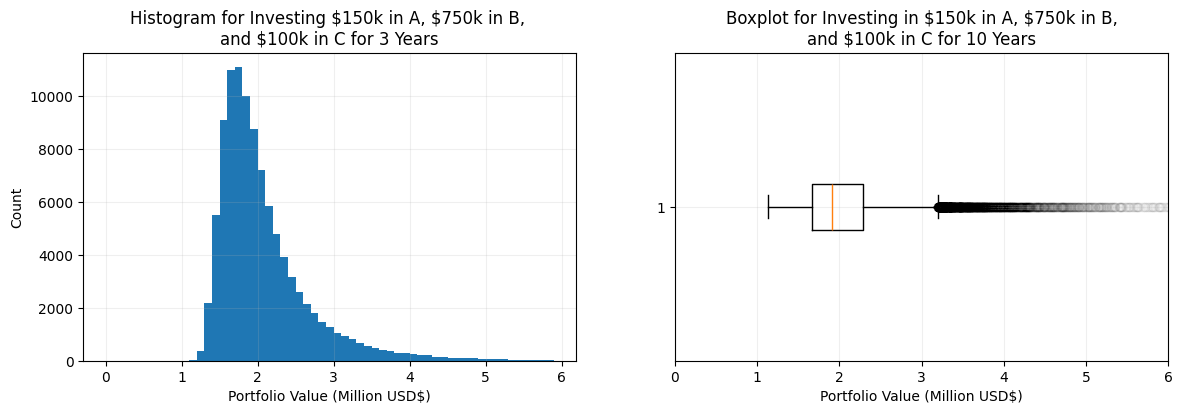

In [349]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(0, 6000000, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$150k in A, \$750k in B, " + "\n" \
r"and \$100k in C for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(0, 6000001, 1000000), list(np.arange(0, 7, 1))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$150k in A, \$750k in B," + "\n" \
r"and \$100k in C for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(0, 6000001, 1000000), list(np.arange(0, 7, 1))) # type: ignore
ax2.set_xlim(0, 6000001)

plt.show()

##### How about investing `$250,000` in each fund?

We start with simulating for 3 years:

In [343]:
portfolios = setup_portfolios([250000.0, 250000.0, 250000.0, 250000.0], NUM_SIMS)
simulate_multiple(portfolios, SHORT_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

SHORT_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $1,243,957.68
Mean return: 24.40%
Standard Deviation: $164,307.30

Median: $1,217,149.39
Median return: 21.71%
Min: $873,938.18
Max: $2,015,031.81
Q1 (25th percentile): $1,123,036.64
Q3 (75th percentile): $1,338,899.22
IQR: $215,862.58

Percentage of failed portfolios: 2.81%
Percentage of outliers: 1.87%

Risk-averse score: 1182
Risk-neutral score: 1219
Risk-seeking score: 1244



Graphs for 3 years:

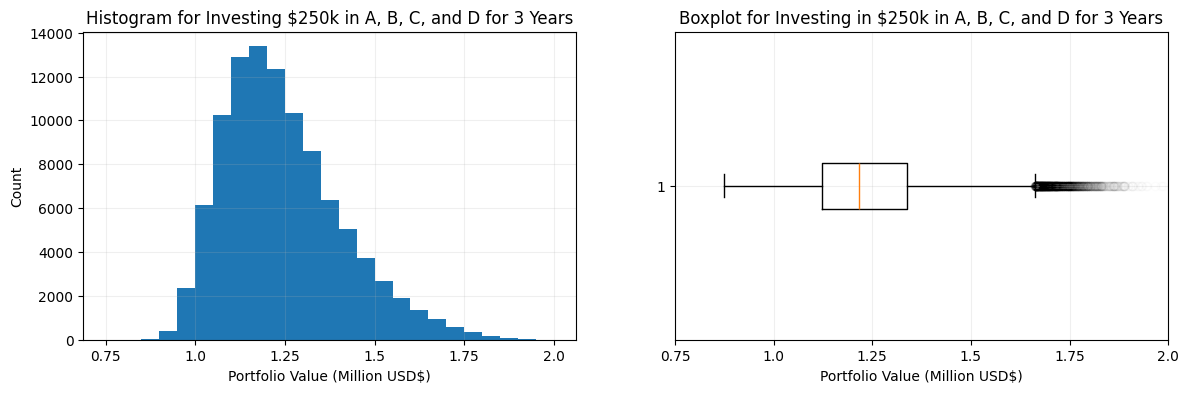

In [344]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(750000, 2000001, 50000)) # each bin will be 25k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$250k in A, B, C, and D for 3 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(750000, 2000001, 250000), list(np.arange(0.75, 2.001, 0.25))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.01})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$250k in A, B, C, and D for 3 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xticks(range(750000, 2000001, 250000), list(np.arange(0.75, 2.01, 0.25))) # type: ignore
ax2.set_xlim(750000, 2000001)

plt.show()

Now we simulate for 10 years:

In [345]:
portfolios = setup_portfolios([250000.0, 250000.0, 250000.0, 250000.0], NUM_SIMS)
simulate_multiple(portfolios, LONG_TERM_YEARS)

portfolio_totals = get_portfolio_totals(portfolios)

LONG_TERM_SCORES.append(get_scores(portfolio_totals))
print_stats(portfolio_totals)

Stats:
Mean: $2,083,730.53
Mean return: 108.37%
Standard Deviation: $652,464.99

Median: $1,907,951.27
Median return: 90.80%
Min: $1,126,598.95
Max: $11,723,569.26
Q1 (25th percentile): $1,672,578.47
Q3 (75th percentile): $2,283,141.16
IQR: $610,562.69

Percentage of failed portfolios: 0.00%
Percentage of outliers: 5.91%

Risk-averse score: 1827
Risk-neutral score: 1921
Risk-seeking score: 1996



Graphs for 10 years:

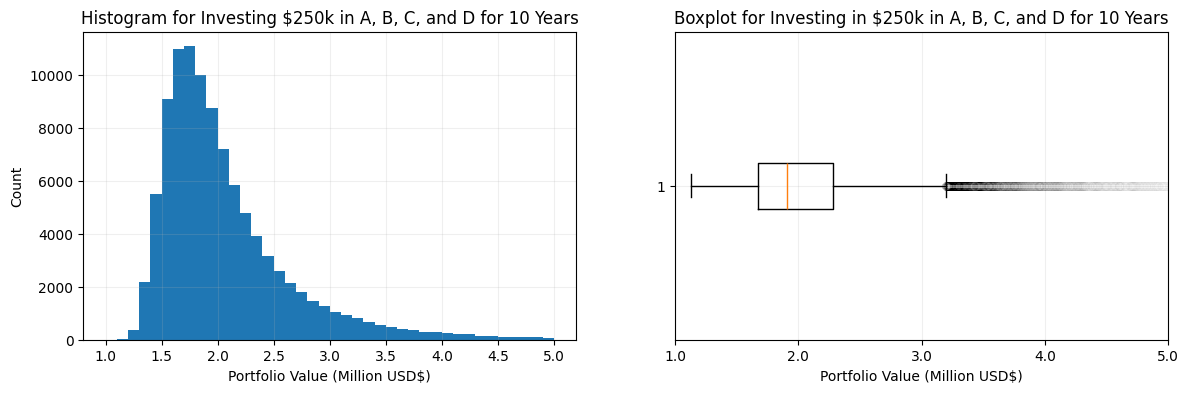

In [346]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

histogram = ax1.hist(portfolio_totals, bins=range(1000000, 5000001, 100000)) # each bin will be 100k
ax1.grid(alpha=0.2)
ax1.set_title(r"Histogram for Investing \$250k in A, B, C, and D for 10 Years")
ax1.set_xlabel("Portfolio Value (Million USD$)")
ax1.set_xticks(range(1000000, 5000001, 500000), list(np.arange(1, 5.01, 0.5))) # type: ignore
ax1.set_ylabel("Count")

box_plot = ax2.boxplot(portfolio_totals, vert=False, flierprops={"alpha": 0.005})
ax2.grid(alpha=0.2)
ax2.set_title(r"Boxplot for Investing in \$250k in A, B, C, and D for 10 Years")
ax2.set_xlabel("Portfolio Value (Million USD$)")
ax2.set_xlim(1000000, 5000000)
ax2.set_xticks(range(1000000, 5000001, 1000000), list(np.arange(1, 5.1, 1))) # type: ignore

plt.show()

### Question 5:

##### What is the best strategy you would recommend?

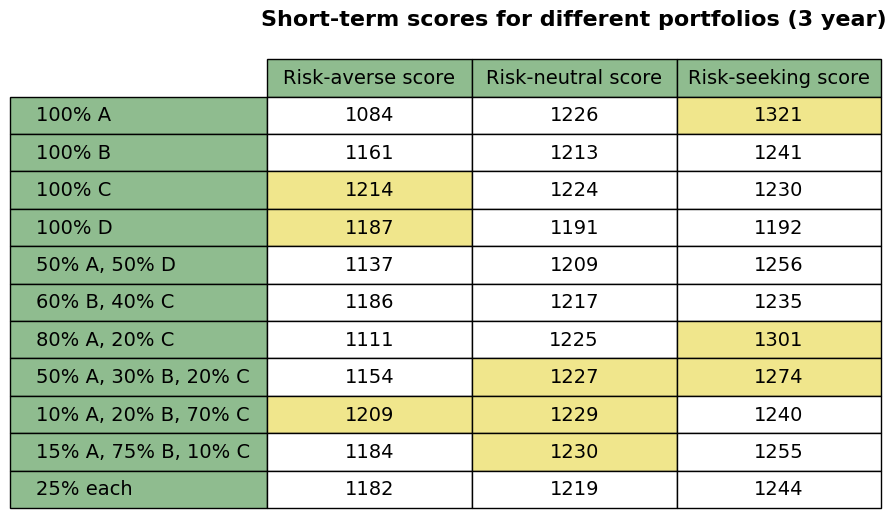

In [357]:
fig, ax = plt.subplots()
ax.axis('off')
ax.axis('tight')
ax.set_title("Short-term scores for different portfolios (3 year)", fontweight="bold", fontsize=16, pad=20)

table = ax.table(
    cellText=SHORT_TERM_SCORES,
    rowLabels=["100% A", "100% B", "100% C", "100% D", "50% A, 50% D",
               "60% B, 40% C", "80% A, 20% C", "50% A, 30% B, 20% C",
               "10% A, 20% B, 70% C", "15% A, 75% B, 10% C", "25% each"],
    colLabels=["Risk-averse score", "Risk-neutral score", "Risk-seeking score"],
    cellLoc="center",
    loc="center",
    rowColours=["darkseagreen"] * len(SHORT_TERM_SCORES),
    colColours=["darkseagreen"] * 3
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.8)  # increase row height

# highlighting max score for each column
for i in range(3):
    col_values = [score[i] for score in SHORT_TERM_SCORES]
    max_3_values = sorted(col_values, reverse=True)[:3]
    for j, value in enumerate(col_values):
        if value in max_3_values:  # give some tolerance for max contender
            table[j + 1, i].set_facecolor("khaki")

# remove extra margins so table fills the axes (no gap at the top)
fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)

plt.show()

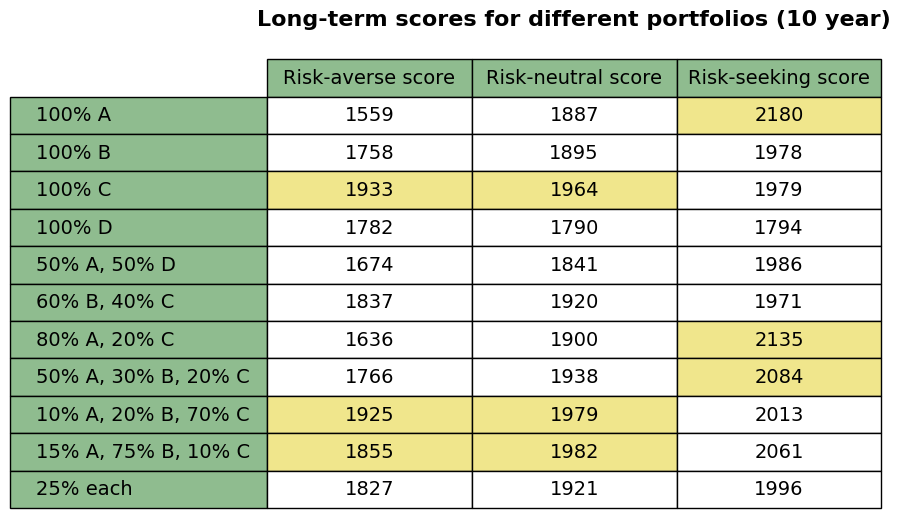

In [358]:
fig, ax = plt.subplots()
ax.axis('off')
ax.axis('tight')
ax.set_title("Long-term scores for different portfolios (10 year)", fontweight="bold", fontsize=16, pad=20)

table = ax.table(
    cellText=LONG_TERM_SCORES,
    rowLabels=["100% A", "100% B", "100% C", "100% D", "50% A, 50% D",
               "60% B, 40% C", "80% A, 20% C", "50% A, 30% B, 20% C",
               "10% A, 20% B, 70% C", "15% A, 75% B, 10% C", "25% each"],
    colLabels=["Risk-averse score", "Risk-neutral score", "Risk-seeking score"],
    cellLoc="center",
    loc="center",
    rowColours=["darkseagreen"] * len(LONG_TERM_SCORES),
    colColours=["darkseagreen"] * 3
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.8)  # increase row height

# highlighting max score for each column
for i in range(3):
    col_values = [score[i] for score in LONG_TERM_SCORES]
    max_3_values = sorted(col_values, reverse=True)[:3]
    for j, value in enumerate(col_values):
        if value in max_3_values:
            table[j + 1, i].set_facecolor("khaki")

# remove extra margins so table fills the axes (no gap at the top)
fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)

plt.show()

markdown block: ***will put answer here !!!***